<a href="https://colab.research.google.com/github/rafael-guimaraes/calculo-numerico/blob/main/Atividade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade I - Cálculo Númerico - Noturno - Profa. Dra. Raquel Lobosco

Nome: Rafael Augusto Guimaraes da Silva


Nome: Joao Pedro Araujo Costa

# CONFIGURACAO PADRAO

In [ ]:

# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")


Ambiente preparado com sucesso!


# Parte A - Truncamento e Arredondamento

In [ ]:
valores = []
valores.append(3.14159265)
valores.append(98.76543)
valores.append(0.00498765)


def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator
for j in range(3):
  print(f"Truncamento e arredondamento do valor: {valores[j]}")
  for i in range(5):
    print(f"truncar({valores[j]}, {i}) = {truncar(valores[j], i)}")
    print(f"round({valores[j]}, {i}) = {round(valores[j],i)}")
  print()


Truncamento e arredondamento do valor: 3.14159265
truncar(3.14159265, 0) = 3.0
round(3.14159265, 0) = 3.0
truncar(3.14159265, 1) = 3.1
round(3.14159265, 1) = 3.1
truncar(3.14159265, 2) = 3.14
round(3.14159265, 2) = 3.14
truncar(3.14159265, 3) = 3.141
round(3.14159265, 3) = 3.142
truncar(3.14159265, 4) = 3.1415
round(3.14159265, 4) = 3.1416

Truncamento e arredondamento do valor: 98.76543
truncar(98.76543, 0) = 98.0
round(98.76543, 0) = 99.0
truncar(98.76543, 1) = 98.7
round(98.76543, 1) = 98.8
truncar(98.76543, 2) = 98.76
round(98.76543, 2) = 98.77
truncar(98.76543, 3) = 98.765
round(98.76543, 3) = 98.765
truncar(98.76543, 4) = 98.7654
round(98.76543, 4) = 98.7654

Truncamento e arredondamento do valor: 0.00498765
truncar(0.00498765, 0) = 0.0
round(0.00498765, 0) = 0.0
truncar(0.00498765, 1) = 0.0
round(0.00498765, 1) = 0.0
truncar(0.00498765, 2) = 0.0
round(0.00498765, 2) = 0.0
truncar(0.00498765, 3) = 0.004
round(0.00498765, 3) = 0.005
truncar(0.00498765, 4) = 0.0049
round(0.00498765

# Parte B - Medidas de pressão arterial

## B.1 - Representacao das medidas

In [ ]:
dados_originais = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
dados_truncados = [truncar(i, 0) for i in dados_originais]
dados_arredondados = [round(i, 0) for i in dados_originais]

def media(valores):
	soma = 0
	cont = 0
	for i in valores:
		soma += i
		cont += 1

	if cont == 0: return 0
	return soma / cont


def desvio_padrao_amostral(valores):
	cont = 0
	for i in valores:
		cont += 1

	if cont <= 1: return 0

	med = media(valores)
	soma_quadrados = 0
	for i in valores:
		soma_quadrados += (i - med) ** 2

	variancia = soma_quadrados / (cont - 1)
	return variancia ** 0.5

series = {
	"Originais": dados_originais,
	"Truncados": dados_truncados,
	"Arredondados": dados_arredondados
}

for nome, dados in series.items():
	print(f"--- Série: {nome} ---")
	print(f"Mínimo: {min(dados)}")
	print(f"Máximo: {max(dados)}")
	print(f"Média: {media(dados):.4f}")
	print(f"Desvio Padrão (Amostral): {desvio_padrao_amostral(dados):.4f}\n")



--- Série: Originais ---
Mínimo: 119.8
Máximo: 122.4
Média: 121.1200
Desvio Padrão (Amostral): 0.8337

--- Série: Truncados ---
Mínimo: 119.0
Máximo: 122.0
Média: 120.7000
Desvio Padrão (Amostral): 0.9487

--- Série: Arredondados ---
Mínimo: 120.0
Máximo: 122.0
Média: 121.1000
Desvio Padrão (Amostral): 0.8756



In [ ]:
media_referencia = media(series["Originais"])

print(f"--- Erro da Média em Relação à Média de Referência (Originais = {media_referencia:.4f}) ---")

for nome, dados in series.items():
    med = media(dados)
    erro = abs(med - media_referencia)
    print(f"Série {nome}: {erro:.4f}")

--- Erro da Média em Relação à Média de Referência (Originais = 121.1200) ---
Série Originais: 0.0000
Série Truncados: 0.4200
Série Arredondados: 0.0200


## B.2 - Gráficos obrigatorios

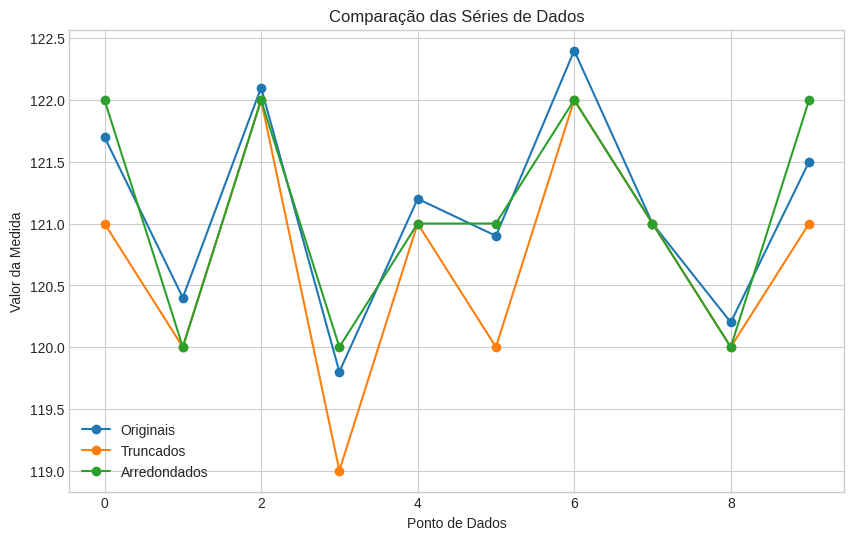

In [ ]:
plt.figure(figsize=(10, 6))

for nome, dados in series.items():
    plt.plot(dados, label=nome, marker='o')

plt.title('Comparação das Séries de Dados')
plt.xlabel('Ponto de Dados')
plt.ylabel('Valor da Medida')
plt.legend()
plt.grid(True)
plt.show()

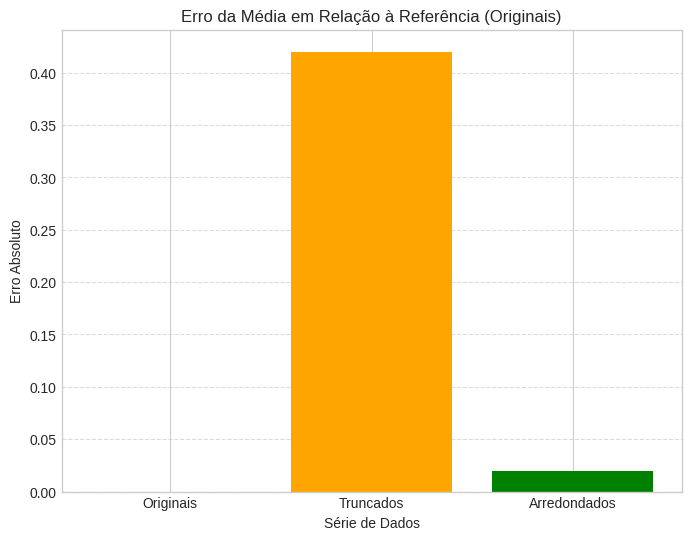

In [ ]:
erros = {}
media_ref = media(series["Originais"])

for nome, dados in series.items():
    erros[nome] = abs(media(dados) - media_ref)

plt.figure(figsize=(8, 6))
plt.bar(erros.keys(), erros.values(), color=['blue', 'orange', 'green'])

plt.title('Erro da Média em Relação à Referência (Originais)')
plt.ylabel('Erro Absoluto')
plt.xlabel('Série de Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

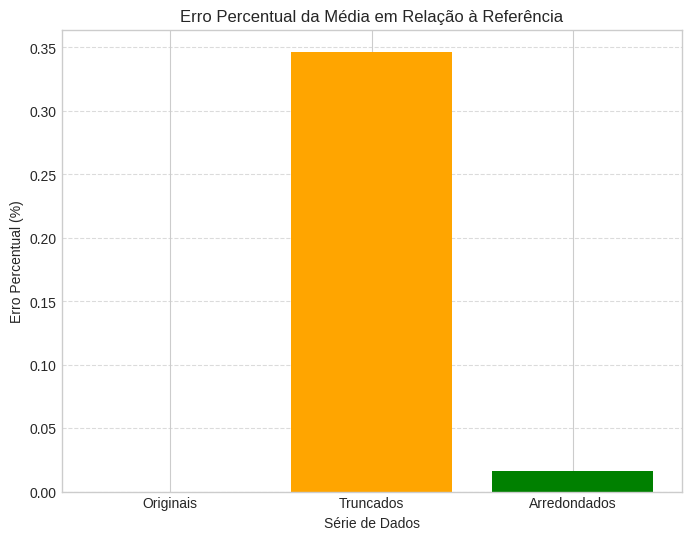

In [ ]:
erros_percentuais = {}
media_ref = media(series["Originais"])

for nome, dados in series.items():
    erro_absoluto = abs(media(dados) - media_ref)
    erros_percentuais[nome] = (erro_absoluto / media_ref) * 100

plt.figure(figsize=(8, 6))
plt.bar(erros_percentuais.keys(), erros_percentuais.values(), color=['blue', 'orange', 'green'])

plt.title('Erro Percentual da Média em Relação à Referência')
plt.ylabel('Erro Percentual (%)')
plt.xlabel('Série de Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

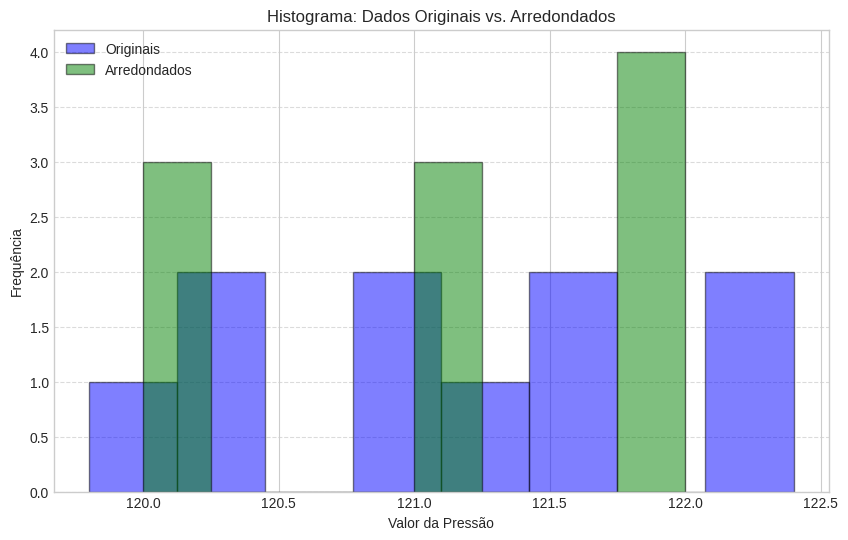

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(series['Originais'], bins=8, alpha=0.5, label='Originais', color='blue', edgecolor='black')
plt.hist(series['Arredondados'], bins=8, alpha=0.5, label='Arredondados', color='green', edgecolor='black')

plt.title('Histograma: Dados Originais vs. Arredondados')
plt.xlabel('Valor da Pressão')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pelos gráficos obtidos, observamos que a variabilidade, a qual observamos no histograma, é bastante prejudicada, pois temos uma centralizacao dos valores nos pontos inteiros. Já na média observamos que a aproximacao nao causa um erro tao grande, especialmente na serie arredondado, pois o arredondamento faz com que os valores, náo se alterem tanto e os erros acabam se anulando tambem.

# Parte C - Vazão em um tubo de pequeno diâmetro

## C.1 - Precisão das variaveis

In [31]:
def calcularQ(r, L, mi, delta_p):
  return math.pi * r**4 * delta_p / (8 * L * mi)

r = 0.80
L = 0.20
mi = 3.5e-3
delta_p = 1200

Q_original = calcularQ(r, L, mi, delta_p)

# Dicionário para armazenar todos os cenários de teste
scenarios = {
    "r Arredondado": calcularQ(round(r, 1), L, mi, delta_p),
    "r Truncado": calcularQ(truncar(r, 1), L, mi, delta_p),
    "mi Arredondado": calcularQ(r, L, round(mi, 3), delta_p),
    "mi Truncado": calcularQ(r, L, truncar(mi, 3), delta_p),
    "delta_p Arredondado": calcularQ(r, L, mi, round(delta_p, -2)),
    "delta_p Truncado": calcularQ(r, L, mi, truncar(delta_p, -2)),
    "Tudo Arredondado": calcularQ(round(r, 1), L, round(mi, 3), round(delta_p, -2)),
    "Tudo Truncado": calcularQ(truncar(r, 1), L, truncar(mi, 3), truncar(delta_p, -2))
}

print(f"Vazão Original (Referência): {Q_original:.4f}\n")

print(f"{'Cenário':<25} | {'Valor Q':<12} | {'Erro Absoluto':<15} | {'Erro Relat. (%)':<15}")
print("-" * 75)

for nome, Q_calc in scenarios.items():
    erro_abs = abs(Q_calc - Q_original)
    erro_rel = (erro_abs / Q_original) * 100
    print(f"{nome:<25} | {Q_calc:<12.4f} | {erro_abs:<15.4f} | {erro_rel:<15.4f}%")

Vazão Original (Referência): 275742.0752

Cenário                   | Valor Q      | Erro Absoluto   | Erro Relat. (%)
---------------------------------------------------------------------------
r Arredondado             | 275742.0752  | 0.0000          | 0.0000         %
r Truncado                | 275742.0752  | 0.0000          | 0.0000         %
mi Arredondado            | 241274.3158  | 34467.7594      | 12.5000        %
mi Truncado               | 321699.0877  | 45957.0125      | 16.6667        %
delta_p Arredondado       | 275742.0752  | 0.0000          | 0.0000         %
delta_p Truncado          | 275742.0752  | 0.0000          | 0.0000         %
Tudo Arredondado          | 241274.3158  | 34467.7594      | 12.5000        %
Tudo Truncado             | 321699.0877  | 45957.0125      | 16.6667        %


## C.2 - Sensibilidade

In [32]:
import numpy as np
import matplotlib.pyplot as plt

L_val = 0.20
mi_val = 3.5e-3
delta_p_val = 1200

raios_originais = np.linspace(0.70, 0.90, 50)

q_ref = []
q_arr = []
q_tru = []

for r_val in raios_originais:
    q_ref.append(calcularQ(r_val, L_val, mi_val, delta_p_val))

    r_round = round(r_val, 1)
    q_arr.append(calcularQ(r_round, L_val, mi_val, delta_p_val))

    r_trunc = truncar(r_val, 1)
    q_tru.append(calcularQ(r_trunc, L_val, mi_val, delta_p_val))

q_ref = np.array(q_ref)
q_arr = np.array(q_arr)
q_tru = np.array(q_tru)

erro_abs_arr = np.abs(q_arr - q_ref)
erro_rel_arr = erro_abs_arr / q_ref
erro_pct_arr = erro_rel_arr * 100

erro_abs_tru = np.abs(q_tru - q_ref)
erro_rel_tru = erro_abs_tru / q_ref
erro_pct_tru = erro_rel_tru * 100

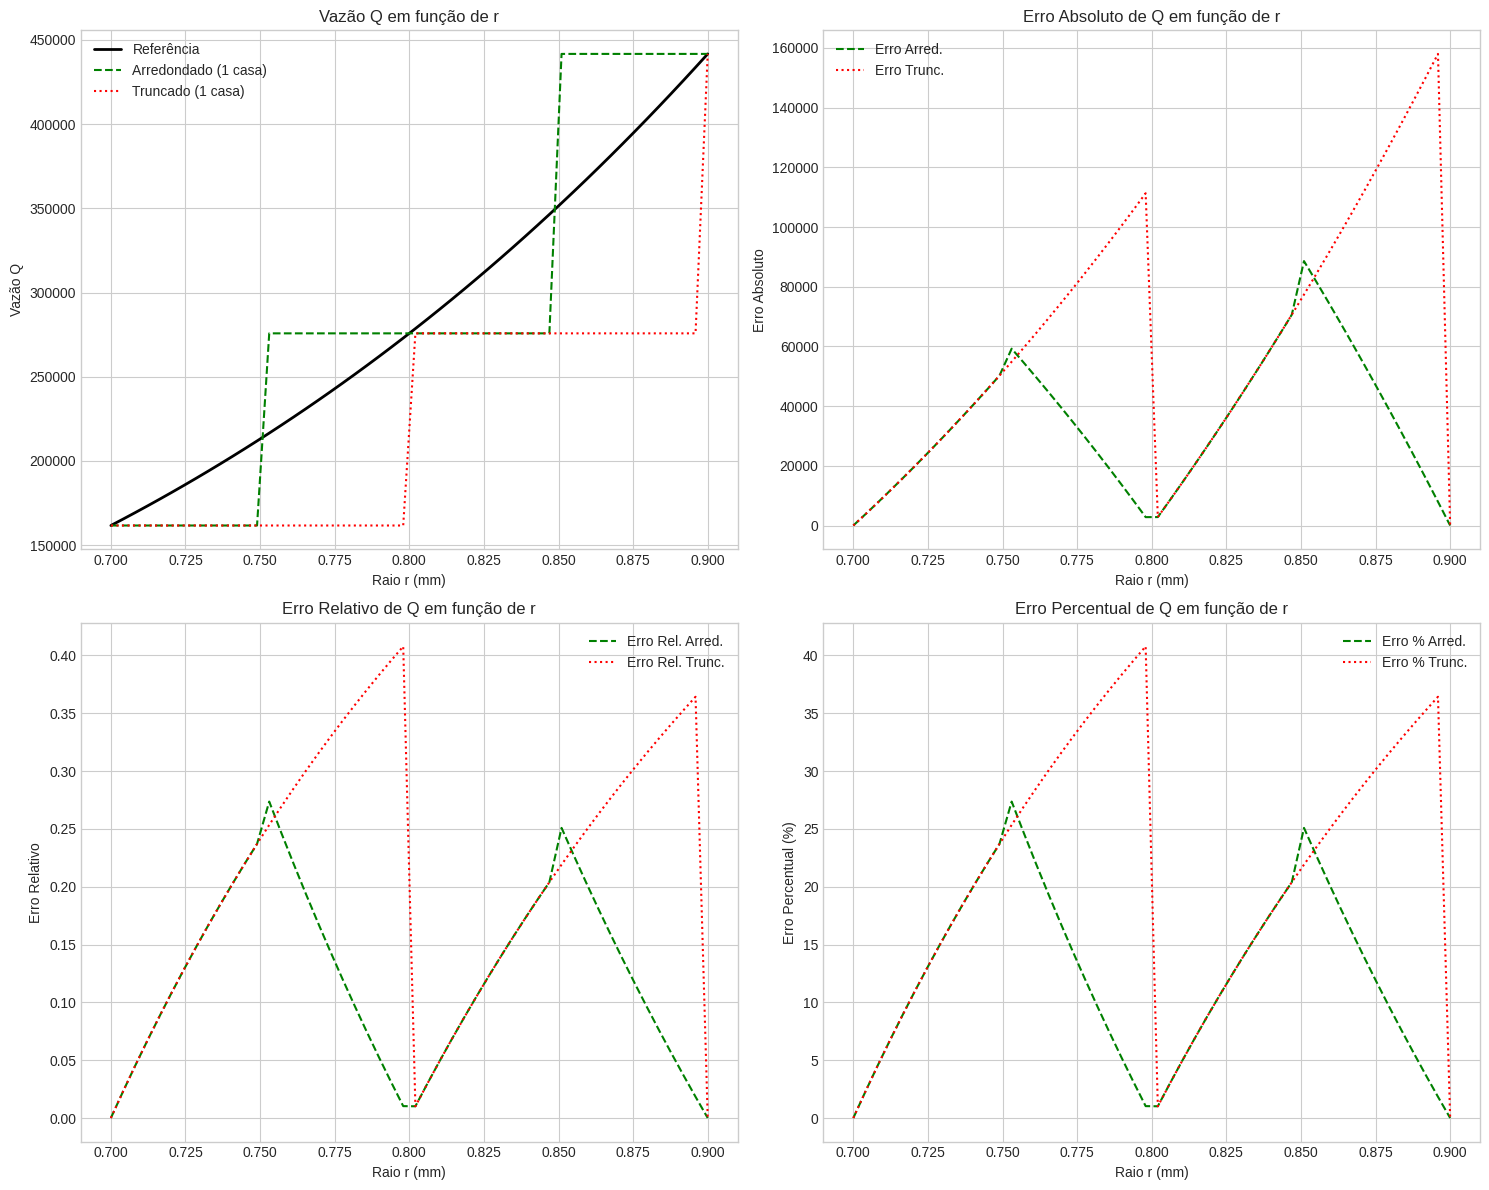

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(raios_originais, q_ref, 'k-', label='Referência', linewidth=2)
axs[0, 0].plot(raios_originais, q_arr, 'g--', label='Arredondado (1 casa)')
axs[0, 0].plot(raios_originais, q_tru, 'r:', label='Truncado (1 casa)')
axs[0, 0].set_title('Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio r (mm)')
axs[0, 0].set_ylabel('Vazão Q')
axs[0, 0].legend()

axs[0, 1].plot(raios_originais, erro_abs_arr, 'g--', label='Erro Arred.')
axs[0, 1].plot(raios_originais, erro_abs_tru, 'r:', label='Erro Trunc.')
axs[0, 1].set_title('Erro Absoluto de Q em função de r')
axs[0, 1].set_xlabel('Raio r (mm)')
axs[0, 1].set_ylabel('Erro Absoluto')
axs[0, 1].legend()

axs[1, 0].plot(raios_originais, erro_rel_arr, 'g--', label='Erro Rel. Arred.')
axs[1, 0].plot(raios_originais, erro_rel_tru, 'r:', label='Erro Rel. Trunc.')
axs[1, 0].set_title('Erro Relativo de Q em função de r')
axs[1, 0].set_xlabel('Raio r (mm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()

axs[1, 1].plot(raios_originais, erro_pct_arr, 'g--', label='Erro % Arred.')
axs[1, 1].plot(raios_originais, erro_pct_tru, 'r:', label='Erro % Trunc.')
axs[1, 1].set_title('Erro Percentual de Q em função de r')
axs[1, 1].set_xlabel('Raio r (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

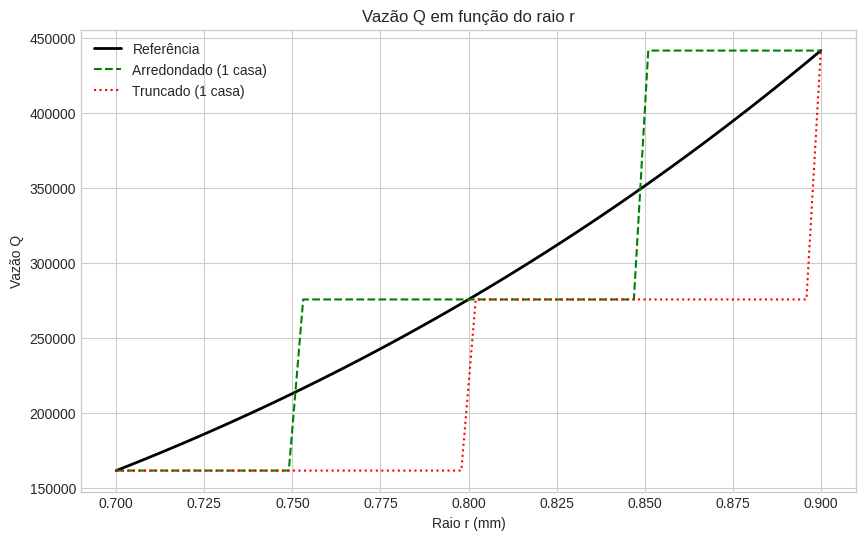

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, q_ref, 'k-', label='Referência', linewidth=2)
plt.plot(raios_originais, q_arr, 'g--', label='Arredondado (1 casa)')
plt.plot(raios_originais, q_tru, 'r:', label='Truncado (1 casa)')
plt.title('Vazão Q em função do raio r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Vazão Q')
plt.legend()
plt.grid(True)
plt.show()

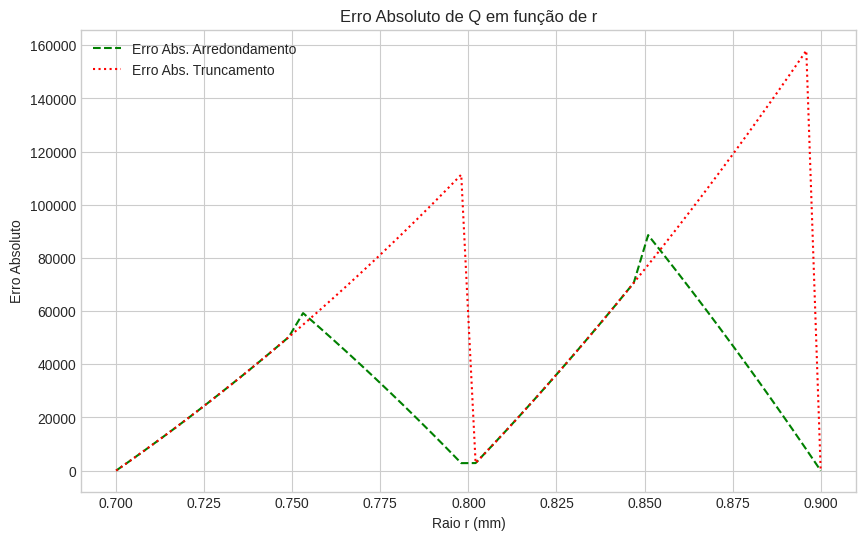

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_abs_arr, 'g--', label='Erro Abs. Arredondamento')
plt.plot(raios_originais, erro_abs_tru, 'r:', label='Erro Abs. Truncamento')
plt.title('Erro Absoluto de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Absoluto')
plt.legend()
plt.grid(True)
plt.show()

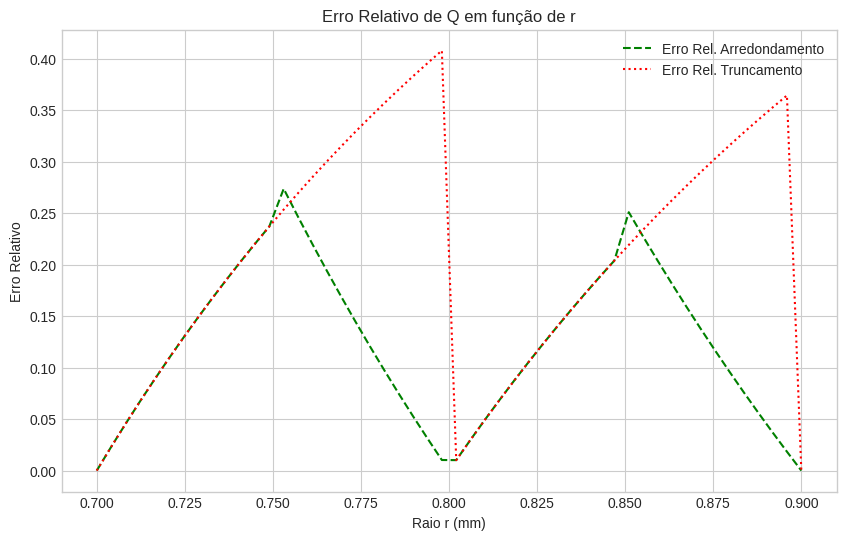

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_rel_arr, 'g--', label='Erro Rel. Arredondamento')
plt.plot(raios_originais, erro_rel_tru, 'r:', label='Erro Rel. Truncamento')
plt.title('Erro Relativo de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Relativo')
plt.legend()
plt.grid(True)
plt.show()

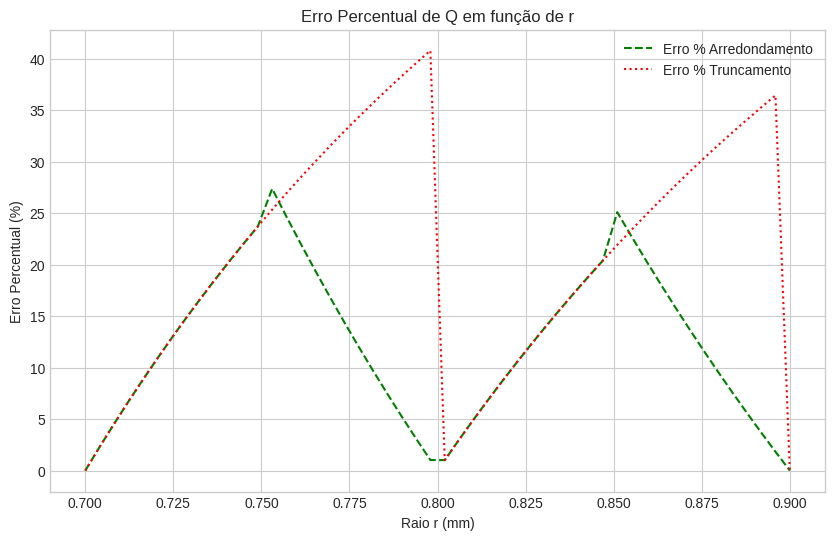

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_pct_arr, 'g--', label='Erro % Arredondamento')
plt.plot(raios_originais, erro_pct_tru, 'r:', label='Erro % Truncamento')
plt.title('Erro Percentual de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Percentual (%)')
plt.legend()
plt.grid(True)
plt.show()

O erro do raio é amplificado na razao, pois o mesmo está elevada a quarta potência, o que gera uma multiplicacao desse erro. Se os dados de entrada contem pequenas incertezas, as operacoes propagam essas incertezas, entao o erro pode crescer rapidamente.

# Parte D - Escoamento em um nanocateter

## D.1 - Erro geometrico

In [38]:
import numpy as np
import matplotlib.pyplot as plt

r_nano = 50.0
L_nano = 10.0
mi_nano = 3.5e-3
delta_p_nano = 5000

delta_rs = np.linspace(0.1, 5.0, 50)

Q_nom = calcularQ(r_nano, L_nano, mi_nano, delta_p_nano)

q_minus = []
q_plus = []
erro_abs_max = []

for dr in delta_rs:
    rm = r_nano - dr
    rp = r_nano + dr
    qm = calcularQ(rm, L_nano, mi_nano, delta_p_nano)
    qp = calcularQ(rp, L_nano, mi_nano, delta_p_nano)

    q_minus.append(qm)
    q_plus.append(qp)

    erro_abs_max.append(max(abs(qm - Q_nom), abs(qp - Q_nom)))

q_minus = np.array(q_minus)
q_plus = np.array(q_plus)
erro_abs_max = np.array(erro_abs_max)

erro_rel_max = erro_abs_max / Q_nom
erro_pct_max = erro_rel_max * 100

erro_rel_linear = 4 * (delta_rs / r_nano)
erro_pct_linear = erro_rel_linear * 100

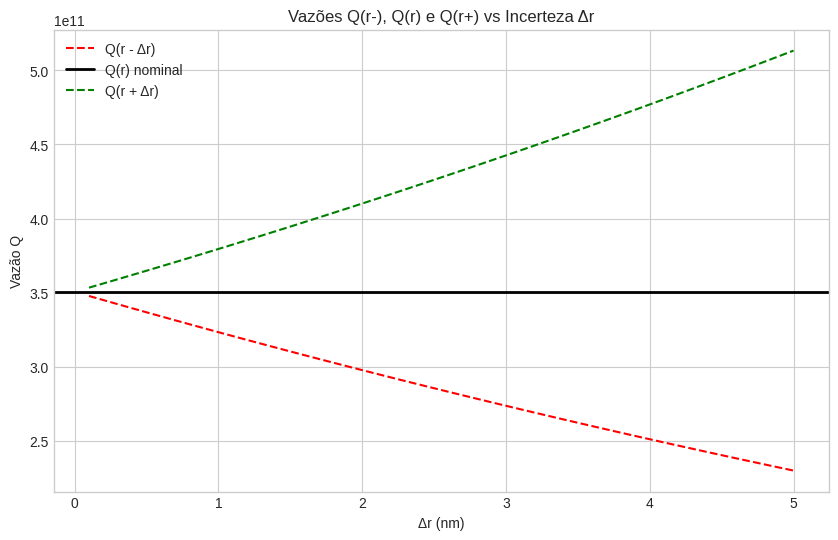

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, q_minus, label='Q(r - Δr)', color='red', linestyle='--')
plt.axhline(y=Q_nom, color='black', label='Q(r) nominal', linewidth=2)
plt.plot(delta_rs, q_plus, label='Q(r + Δr)', color='green', linestyle='--')
plt.title('Vazões Q(r-), Q(r) e Q(r+) vs Incerteza Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Vazão Q')
plt.legend()
plt.grid(True)
plt.show()

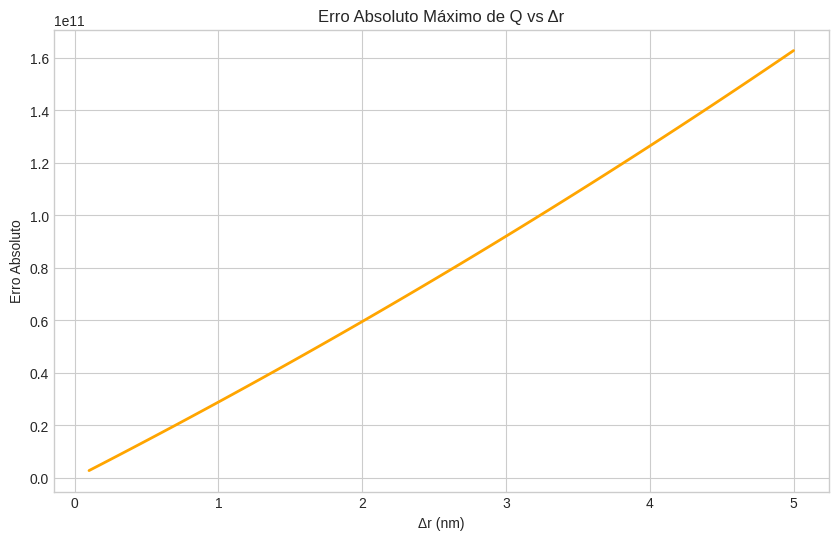

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_abs_max, color='orange', linewidth=2)
plt.title('Erro Absoluto Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Absoluto')
plt.grid(True)
plt.show()

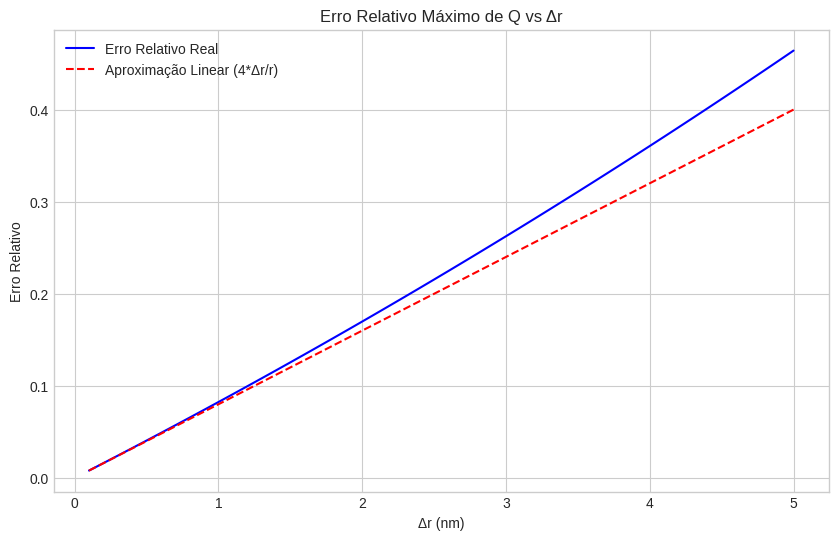

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_rel_max, 'b-', label='Erro Relativo Real')
plt.plot(delta_rs, erro_rel_linear, 'r--', label='Aproximação Linear (4*Δr/r)')
plt.title('Erro Relativo Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Relativo')
plt.legend()
plt.grid(True)
plt.show()

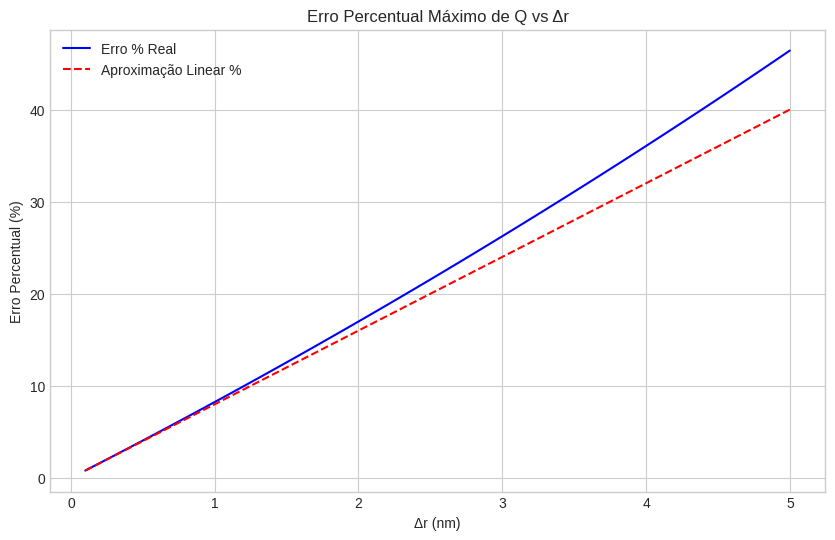

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_pct_max, 'b-', label='Erro % Real')
plt.plot(delta_rs, erro_pct_linear, 'r--', label='Aproximação Linear %')
plt.title('Erro Percentual Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Percentual (%)')
plt.legend()
plt.grid(True)
plt.show()